## First Notebook

## Boilerplate

In [41]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')
from pathlib import Path


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Fun starts here

this is just text

In [3]:
1+1

2

In [4]:
# Hello world
print("Hello world")


Hello world


## Library Imports

In [14]:
# pi

In [7]:
import math

math.pi

3.141592653589793

In [10]:
import src.tools as tools

In [13]:
tools.square_root(9)

3.0

In [18]:
tools.dice_roll()

6

## Fetching from the interwebs

In [19]:
import requests
from IPython.display import Image, display


In [21]:
xkcd = requests.get("https://xkcd.com/353/info.0.json").json()

xkcd

{'month': '12',
 'num': 353,
 'link': '',
 'year': '2007',
 'news': '',
 'safe_title': 'Python',
 'transcript': '[[ Guy 1 is talking to Guy 2, who is floating in the sky ]]\nGuy 1: You\'re flying! How?\nGuy 2: Python!\nGuy 2: I learned it last night! Everything is so simple!\nGuy 2: Hello world is just \'print "Hello, World!" \'\nGuy 1: I dunno... Dynamic typing? Whitespace?\nGuy 2: Come join us! Programming is fun again! It\'s a whole new world up here!\nGuy 1: But how are you flying?\nGuy 2: I just typed \'import antigravity\'\nGuy 1: That\'s it?\nGuy 2: ...I also sampled everything in the medicine cabinet for comparison.\nGuy 2: But i think this is the python.\n{{ I wrote 20 short programs in Python yesterday.  It was wonderful.  Perl, I\'m leaving you. }}',
 'alt': "I wrote 20 short programs in Python yesterday.  It was wonderful.  Perl, I'm leaving you.",
 'img': 'https://imgs.xkcd.com/comics/python.png',
 'title': 'Python',
 'day': '5'}

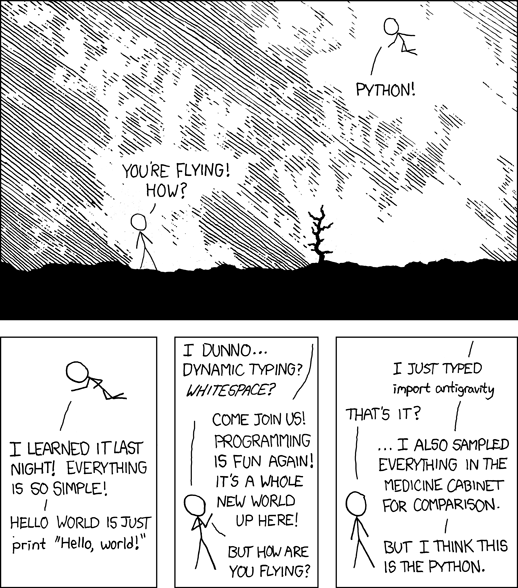

In [22]:
Image(xkcd['img'])


## Lets get some GIS data

In [29]:
from src.tools import load_featureserver_to_gdf

url = "https://services1.arcgis.com/ZIL9uO234SBBPGL7/arcgis/rest/services/Denver_Parkway_Trees_OG/FeatureServer"
gdf = load_featureserver_to_gdf(url)

print(gdf.shape)
gdf.head()

(353164, 26)


,FID,GlobalID,SITE_ID,SPECIES_CO,SPECIES_BO,DIAMETER,STEMS,CONDITION,LOCATION_N,LOCATION_C,SITE_DESIG,INVENTORY_,STRUCTURAL,DISEASE_PE,EAB_TAG,RISK_TAG,TARGET_CLA,ADDRESS,STREET,NEIGHBOR,COMMENTS,X_LONG,Y_LAT,WORKGROUP,NOTABLE,geometry
0,1,a59a6eaa-ac61-43fb-b53a-b9132ae20430,0,"Pear, Flowering",Pyrus calleryana,6 to 12,1,Good,0 Non-park tree,N/A,Street Tree,1397692800000,N/A,N/A,,Unassigned,N/A,3917,E 26TH AVENUE PKWY,Skyland,DBH @ <4.5 ft,-104.941165,39.754512,Inspections,N/A,POINT (-11681997.017 4830332.437)
1,2,4e139777-ae77-42b2-88dd-0d4b7a1663bf,0,"Pear, Flowering",Pyrus calleryana,6 to 12,1,Good,0 Non-park tree,N/A,Street Tree,1397692800000,N/A,N/A,,Unassigned,N/A,3917,E 26TH AVENUE PKWY,Skyland,DBH @ <4.5 ft,-104.941286,39.754512,Inspections,N/A,POINT (-11682010.503 4830332.425)
2,3,6b518d84-b801-4180-9a54-280177dbf7b8,0,"Spruce, Blue",Picea pungens,12 to 18,1,Good,0 Non-park tree,N/A,Street Tree,1397692800000,N/A,N/A,,Unassigned,N/A,3915,E 26TH AVENUE PKWY,Skyland,,-104.941339,39.754523,Inspections,N/A,POINT (-11682016.471 4830334.144)
3,4,4cca414c-1b86-4c91-8a97-e43d5f5a5278,0,Crabapple,Malus tschonoskii,12 to 18,1,Fair,0 Non-park tree,N/A,Street Tree,1397692800000,N/A,N/A,,Unassigned,N/A,3915,E 26TH AVENUE PKWY,Skyland,DBH @ <4.5 ft,-104.941397,39.754523,Inspections,N/A,POINT (-11682022.878 4830334.088)
4,5,e61d801c-9a84-478c-9dc9-5df598a530bf,0,Crabapple,Malus tschonoskii,12 to 18,1,Fair,0 Non-park tree,N/A,Street Tree,1397692800000,N/A,N/A,,Unassigned,N/A,3915,E 26TH AVENUE PKWY,Skyland,DBH @ <4.5 ft,-104.941512,39.754522,Inspections,N/A,POINT (-11682035.694 4830333.972)


## Visualize

In [30]:
gdf.columns.tolist()

['FID',
 'GlobalID',
 'SITE_ID',
 'SPECIES_CO',
 'SPECIES_BO',
 'DIAMETER',
 'STEMS',
 'CONDITION',
 'LOCATION_N',
 'LOCATION_C',
 'SITE_DESIG',
 'INVENTORY_',
 'STRUCTURAL',
 'DISEASE_PE',
 'EAB_TAG',
 'RISK_TAG',
 'TARGET_CLA',
 'ADDRESS',
 'STREET',
 'NEIGHBOR',
 'COMMENTS',
 'X_LONG',
 'Y_LAT',
 'WORKGROUP',
 'NOTABLE',
 'geometry']

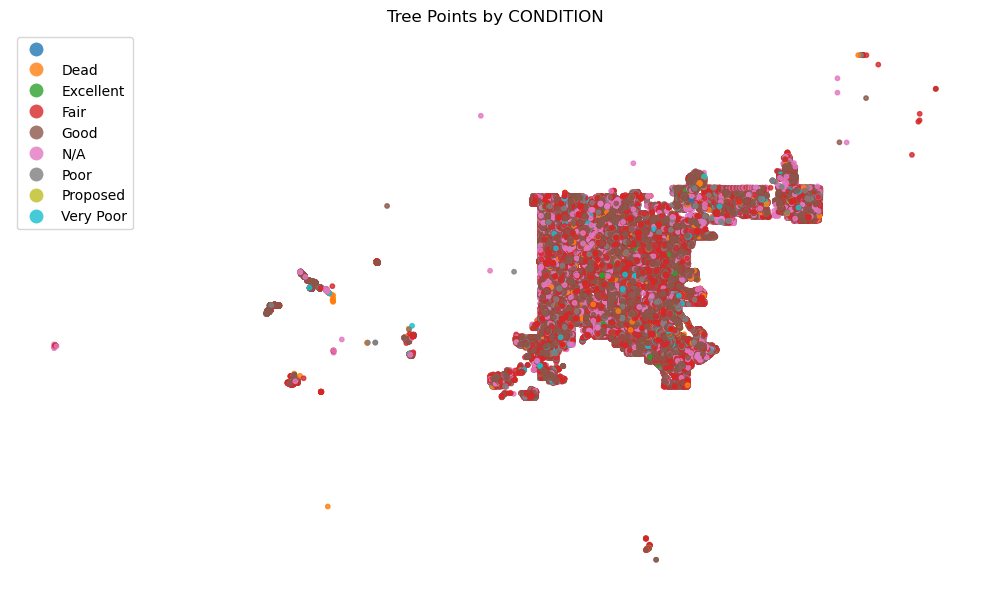

In [32]:
from src.tools import plot_points_by_category

ax = plot_points_by_category(gdf)  # uses CONDITION by default

CONDITION
Fair         136124
Good         131712
N/A           47250
Poor          22635
Dead           6096
Very Poor      5766
Excellent      3570
Proposed          8
                  3
Name: count, dtype: int64
rows: 131712
non-null geometry: 131712


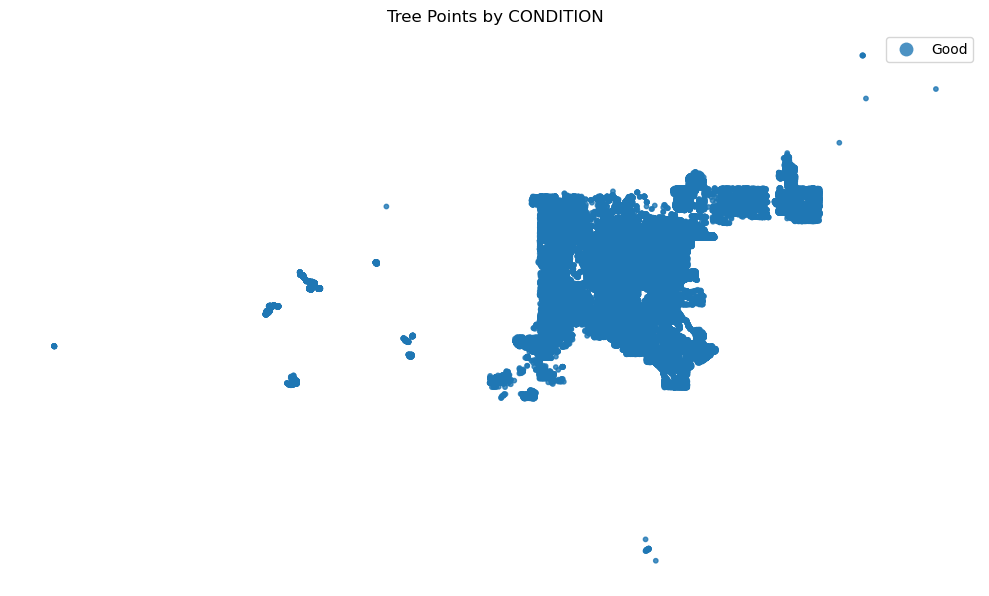

In [35]:
# 1) See actual CONDITION values
print(gdf["CONDITION"].value_counts(dropna=False).head(20))

# 2) Build a safer filter (ignores case + extra spaces)
subset = gdf[gdf["CONDITION"].astype(str).str.strip().str.upper() == "GOOD"]

# 3) Verify rows + geometry
print("rows:", len(subset))
print("non-null geometry:", subset.geometry.notna().sum())

# 4) Plot
ax = plot_points_by_category(subset, "CONDITION")

## Output and save

In [43]:
from pathlib import Path

# Repo root `out/` (not `notebooks/out/`). Matches the demo path fix described in README.
Path("../out").mkdir(parents=True, exist_ok=True)
gdf.to_file("../out/denver_parkway_trees.shp")